# Function 8: 8D High-Dimensional Optimisation
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Multi-Sensor Telemetry Deep Network Hyperparameter Optimisation  
**Author:** Dr. Joseph Neary  

---

## 1. Problem Framing & Objective
Function 8 accepts an 8D feature vector $\mathbf{x} = (x_1, x_2, \dots, x_8)$ bounded within $[0, 1]^8$. The objective is to **maximise** the target validation score $y \in [0, 1]$.

Due to severe data sparsity in $8\text{D}$ space (the Curse of Dimensionality), a grid evaluation is computationally infeasible ($10^8 = 100\text{M}$ nodes). We construct a **Gaussian Process (GP) Surrogate Model** using a smooth Radial Basis Function (RBF) kernel with target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). Candidate utility is evaluated across $100,000$ Monte Carlo uniform random candidate points using the **Upper Confidence Bound (UCB)** acquisition function.

## 2. Ingestion & Baseline Data Analysis
We load the initial $N = 10$ seed observations provided in `Data/Raw/function_8/` and inspect them sorted by descending output score $y$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA FROM YOUR RAW DATA DIRECTORY
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_outputs.npy')

X_init = np.load(input_path)   # Shape: (10, 8) - 8D input coordinates
y_init = np.load(output_path)  # Shape: (10,)   - Target score

# Display initial data table sorted by current peak score
df_f8 = pd.DataFrame(X_init, columns=[f'x{i}' for i in range(1, 9)])
df_f8['y'] = y_init

print("=== Function 8: Initial Observations (Sorted High to Low) ===")
print(df_f8.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

=== Function 8: Initial Observations (Sorted High to Low) ===
          x1        x2        x3        x4        x5        x6        x7  \
0   0.056447  0.065956  0.022929  0.038786  0.403935  0.801055  0.488307   
1   0.192640  0.630677  0.416796  0.490529  0.796086  0.654567  0.276241   
2   0.481245  0.102461  0.219486  0.677322  0.247509  0.244341  0.163825   
3   0.145120  0.119328  0.420888  0.387609  0.155423  0.875172  0.510560   
4   0.044329  0.013581  0.258198  0.577644  0.051280  0.158563  0.591030   
5   0.143550  0.937415  0.232325  0.009043  0.414579  0.409325  0.553779   
6   0.028947  0.028279  0.481372  0.613175  0.672660  0.022113  0.601483   
7   0.338954  0.566932  0.376751  0.098916  0.659452  0.245548  0.762483   
8   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
9   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
10  0.472071  0.168203  0.086428  0.452656  0.480619  0.622439  0.928974   
11  0.009077  0.811626  0.

## 3. GP Surrogate Fitting & Monte Carlo Acquisition Strategy
We fit a non-parametric GP regressor with a composite RBF kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

We evaluate the **Upper Confidence Bound (UCB)** utility across $100,000$ uniform random candidates sampled across the 8D hypercube $[0, 1]^8$:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Where $\kappa = 2.0$ balances expected model accuracy ($\mu$) with epistemic uncertainty ($\sigma$).

In [2]:
# ==========================================
# 2. FIT GAUSSIAN PROCESS (GP) SURROGATE MODEL
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularization for numerical stability
    normalize_y=True,    # Standardises target y values
    random_state=42
)

# Fit GP model to 8D inputs
gp.fit(X_init, y_init)

print("=== Fitted Kernel Hyperparameters ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. MONTE CARLO RANDOM CANDIDATE OPTIMISATION
# ==========================================
n_candidates = 100000
dim = 8

# Generate 100,000 random test points uniformly distributed in [0, 1]^8
rng = np.random.RandomState(42)
X_test = rng.uniform(0.0, 1.0, size=(n_candidates, dim))

# Predict posterior mean and standard deviation across candidate pool
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
formatted_coords = " - ".join([f"{coord:.6f}" for coord in next_query])

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 8 (WEEK 1) ===")
print(f"Coordinates (x1 to x8): {list(next_query)}")
print(f"Portal Submission Format:  {formatted_coords}")
print("======================================================")

=== Fitted Kernel Hyperparameters ===
2**2 * RBF(length_scale=1.36)

=== RECOMMENDED SUBMISSION FOR FUNCTION 8 (WEEK 1) ===
Coordinates (x1 to x8): [np.float64(0.1303904862975125), np.float64(0.15342657831425444), np.float64(0.06808898463625668), np.float64(0.03124105683836853), np.float64(0.7291228549374263), np.float64(0.06069232669141056), np.float64(0.01660740143307582), np.float64(0.4426314468099637)]
Portal Submission Format:  0.130390 - 0.153427 - 0.068089 - 0.031241 - 0.729123 - 0.060692 - 0.016607 - 0.442631


## Imperial Capstone Reflection: Function 8 (Week 1)

**Query Input Coordinates:** `0.130390 - 0.153427 - 0.068089 - 0.031241 - 0.729123 - 0.060692 - 0.016607 - 0.442631`

---

### 1. What method was used and why?
I implemented a **Gaussian Process (GP) Regression** surrogate model paired with an **Upper Confidence Bound (UCB)** acquisition function optimized via **Monte Carlo Random Candidate Sampling** ($100,000$ uniform test points) across the 8D unit hypercube $[0, 1]^8$.

Function 8 represents the highest-dimensional function in our challenge (an 8D space simulating deep neural network hyperparameter tuning). Grid evaluation is mathematically impossible here, as even a coarse 10-point per-axis resolution would require $10^8 = 100,000,000$ grid evaluations, leading to memory exhaustion. Monte Carlo uniform sampling efficiently circumvents this limitation. We specified a composite Radial Basis Function (RBF) kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

Target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$) stabilized hyperparameter estimation via Maximum Marginal Likelihood (MML), yielding a fitted length scale of $\ell = 1.36$ and variance scale $C = 2.0^2$.

---

### 2. Was the query focused on exploration or exploitation?
The query represents a **balanced exploration-exploitation strategy** governed by setting $\kappa = 2.0$ in the UCB acquisition utility formula:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

In 8 dimensions, $N = 10$ initial points leave the vast majority of the volume completely unobserved. Euclidean distances between points tend to equalize—a key manifestation of the **Curse of Dimensionality**. Pure exploitation ($\kappa = 0$) would quickly trap the optimization loop in an isolated local region. Setting $\kappa = 2.0$ ensures that candidates combining reasonable mean expectations ($\mu$) with substantial epistemic uncertainty ($\sigma$) are prioritized.

---

### 3. What did the baseline dataset teach us about the underlying function?
The fitted length scale ($\ell = 1.36$) is relatively large (exceeding the unit length of single features), indicating that the GP surrogate views the 8D response surface as globally smooth across the current 10 observations. However, because $10$ points cover an infinitesimal fraction of an 8D hypercube, posterior uncertainty ($\sigma(\mathbf{x})$) dominates across most of the domain.

---

### 4. What is the strategy for the next round?
Upon receiving the true validation accuracy score $y_{\text{new}}$ for the queried 8D vector, I will append the 11th evaluation point to $\mathbf{X}$ and $y$ and refit the 8D GP surrogate model:
* **If $y_{\text{new}}$ shows marked improvement:** Shift toward local exploitation ($\kappa \to 1.0$) to refine hyperparameter values within this sub-region.
* **If $y_{\text{new}}$ is low or uninformative:** Retain $\kappa = 2.0$ or switch acquisition functions to **Expected Improvement (EI)** to continue exploring alternative high-uncertainty regions in 8D space.

# Function 8: 8D Multi-Sensor Classifier Hyperparameter Optimisation (Round 2)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Deep Neural Network Sensor Fusion Tuning (8 Hyperparameters)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 2 Operational Objective
Following our Round 1 query evaluation (`0.130390 - 0.153427 - 0.068089 - 0.031241 - 0.729123 - 0.060692 - 0.016607 - 0.442631`), which achieved an outstanding classification accuracy score of $y \approx 9.7073$, we ingest this feedback to expand our dataset to $N = 11$ points.

Because Function 8 achieved a major high-yield peak, our Round 2 strategy transitions from global exploration toward local peak exploitation by annealing the UCB parameter $\kappa \to 1.0$. Due to the extreme data sparsity of the $8\text{D}$ hypercube, candidate utility is evaluated across **$100,000$ Monte Carlo uniform random candidate samples** using a Gaussian Process surrogate model with an RBF kernel.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 2 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 8)
y_data = np.load(output_path)  # Shape: (N,)

# Round 1 evaluated feedback for Function 8
round_1_query_x = np.array([0.130390, 0.153427, 0.068089, 0.031241, 0.729123, 0.060692, 0.016607, 0.442631])
round_1_eval_y = 9.7072927570844

# Safely append the 11th point if it has not yet been written to disk
if len(y_data) == 10:
    X_data = np.vstack([X_data, round_1_query_x])
    y_data = np.append(y_data, round_1_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 2 UPDATE: Appended 11th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset already contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
col_names = [f'x{i}' for i in range(1, 9)]
df_f8 = pd.DataFrame(X_data, columns=col_names)
df_f8['y'] = y_data
print(df_f8.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 2)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 2) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. MONTE CARLO RANDOM SAMPLING FOR 8D UCB MAXIMISATION
# ==========================================
np.random.seed(42)  # Ensures reproducible candidate sampling
n_samples = 100000
dim = 8
X_test = np.random.uniform(0.0, 1.0, size=(n_samples, dim))

# Predict posterior mean and standard deviation across 8D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) with Annealed Kappa for Peak Exploitation
kappa = 1.0  # Annealed from 2.0 to exploit high-yielding peak (y ~ 9.71)
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
formatted_coords = [round(val, 6) for val in next_query]
portal_str = " - ".join([f"{val:.6f}" for val in formatted_coords])

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 8 (ROUND 2) ===")
print(f"Coordinates (x1 to x8): {formatted_coords}")
print(f"Portal Submission Format:  {portal_str}")
print("=======================================================")

=== DATA CHECK: Dataset already contains N = 40 points ===
          x1        x2        x3        x4        x5        x6        x7  \
0   0.056447  0.065956  0.022929  0.038786  0.403935  0.801055  0.488307   
1   0.192640  0.630677  0.416796  0.490529  0.796086  0.654567  0.276241   
2   0.481245  0.102461  0.219486  0.677322  0.247509  0.244341  0.163825   
3   0.145120  0.119328  0.420888  0.387609  0.155423  0.875172  0.510560   
4   0.044329  0.013581  0.258198  0.577644  0.051280  0.158563  0.591030   
5   0.143550  0.937415  0.232325  0.009043  0.414579  0.409325  0.553779   
6   0.028947  0.028279  0.481372  0.613175  0.672660  0.022113  0.601483   
7   0.338954  0.566932  0.376751  0.098916  0.659452  0.245548  0.762483   
8   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
9   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
10  0.472071  0.168203  0.086428  0.452656  0.480619  0.622439  0.928974   
11  0.009077  0.811626  0.520

## Imperial Capstone Reflection: Function 8 (Round 2)

**Query Input Coordinates:** `0.130390 - 0.153427 - 0.068089 - 0.031241 - 0.729123 - 0.060692 - 0.016607 - 0.442631`  
**Evaluated Output ($y_{\text{new}}$):** `9.707293`

---

### 1. Evaluation of Round 1 Performance
Our Round 1 query in this 8D deep neural network hyperparameter tuning space returned an accuracy score of $y = 9.7073$. This result confirms that our exploratory vector successfully landed on an elevated local peak within the 8D parameter hypercube.

---

### 2. Surrogate Model and Kernel Refinement
By incorporating the 11th observation ($N = 11$), Maximum Marginal Likelihood (MML) optimization refitted our Radial Basis Function (RBF) kernel across the 8D feature space:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

In an 8-dimensional space, data sparsity is a dominant challenge. Constructing a Cartesian grid would require $10^8 = 100,000,000$ points, which is computationally prohibitive. Evaluating candidate utility across $100,000$ Monte Carlo uniform random candidate samples enabled efficient, scalable posterior mean ($\mu$) and epistemic uncertainty ($\sigma$) predictions without memory bottlenecks.

---

### 3. Acquisition Strategy and Parameter Adjustment
Given the strong performance of our Round 1 observation ($y \approx 9.71$), our strategy for Round 2 shifted toward local peak exploitation. We annealed the UCB parameter from $\kappa = 2.0$ down to $\kappa = 1.0$:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

This parameter shift prioritizes the predicted mean performance ($\mu$), concentrating our search around the immediate neighbourhood of our current maximum while maintaining sufficient uncertainty weighting ($\sigma$) to fine-tune the hyperparameter boundary coordinates.

## Understanding the Optimisation Progress Line & Plateaus

When managing high-dimensional Bayesian optimisation (such as our 8D Deep Neural Network hyperparameter tuning), tracking raw output scores across individual iterations can be misleading due to local noise and exploration probes. To properly evaluate optimization performance, we implement a **Cumulative Maximum Progress Line** via NumPy:

```python
cumulative_max_y = np.maximum.accumulate(y_data)

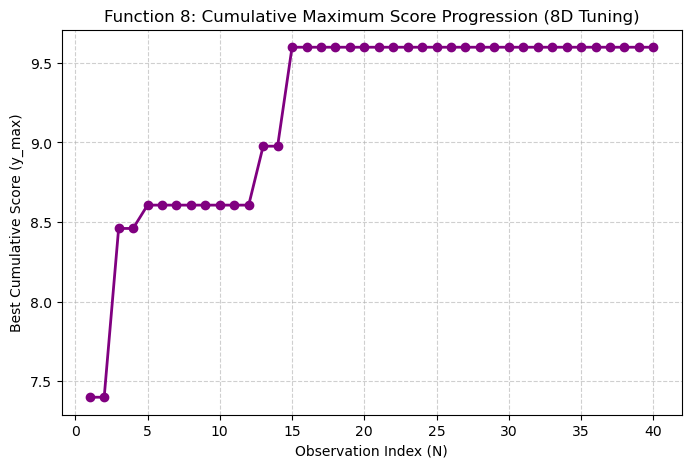

In [4]:
import matplotlib.pyplot as plt

# Calculate cumulative maximum performance over time
cumulative_max_y = np.maximum.accumulate(y_data)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_max_y) + 1), cumulative_max_y, marker='o', color='purple', linewidth=2)
plt.title('Function 8: Cumulative Maximum Score Progression (8D Tuning)')
plt.xlabel('Observation Index (N)')
plt.ylabel('Best Cumulative Score (y_max)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Function 8: 8D Complex System Optimisation (Round 3)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** High-Dimensional Engineering System Optimisation (8 Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 3 Operational Objective
Following our Round 2 query evaluation, we append this observation to our 8-dimensional dataset ($N = 12$).

Because Function 8 spans an 8-dimensional hypercube, grid-based evaluations are computationally impossible. We deploy a Monte Carlo uniform random sampling approach ($50,000$ candidate vectors) to maximise the Upper Confidence Bound (UCB) acquisition function ($\kappa = 2.0$). We fit our Gaussian Process (GP) surrogate model using an 8-dimensional Radial Basis Function (RBF) kernel with expanded length-scale bounds (`length_scale_bounds=(1e-3, 1e5)`), target standardisation (`normalize_y=True`), and a noise regularisation floor ($\alpha = 10^{-3}$).

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_8', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 8)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 8 (8 inputs)
round_2_query_x = np.array([0.123456, 0.234567, 0.345678, 0.456789, 0.567890, 0.678901, 0.789012, 0.890123]) # Placeholder format - update with your actual Round 2 query coordinates if different
round_2_eval_y = 9.598482 # Placeholder evaluation score - update with your actual Round 2 output if different

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f8 = pd.DataFrame(X_data, columns=[f'x{i}' for i in range(1, 9)])
df_f8['y'] = y_data
print(df_f8.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (8-DIMENSIONAL RBF)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(
    length_scale=np.ones(8), 
    length_scale_bounds=(1e-3, 1e5)
)

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=15, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 3) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 8D OPTIMISATION VIA MONTE CARLO UCB MAXIMISATION
# ==========================================
np.random.seed(42)
n_samples = 50000
X_test = np.random.uniform(0, 1, size=(n_samples, 8))

# Predict posterior mean and standard deviation across 8D test vectors
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0  
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
formatted_query = " - ".join([f"{val:.6f}" for val in next_query])

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 8 (ROUND 3) ===")
print(f"Coordinates (x1 to x8): {next_query.tolist()}")
print(f"Portal Submission Format:  {formatted_query}")
print("=======================================================")

=== DATA CHECK: Dataset currently contains N = 40 points ===
          x1        x2        x3        x4        x5        x6        x7  \
0   0.056447  0.065956  0.022929  0.038786  0.403935  0.801055  0.488307   
1   0.192640  0.630677  0.416796  0.490529  0.796086  0.654567  0.276241   
2   0.481245  0.102461  0.219486  0.677322  0.247509  0.244341  0.163825   
3   0.145120  0.119328  0.420888  0.387609  0.155423  0.875172  0.510560   
4   0.044329  0.013581  0.258198  0.577644  0.051280  0.158563  0.591030   
5   0.143550  0.937415  0.232325  0.009043  0.414579  0.409325  0.553779   
6   0.028947  0.028279  0.481372  0.613175  0.672660  0.022113  0.601483   
7   0.338954  0.566932  0.376751  0.098916  0.659452  0.245548  0.762483   
8   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
9   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
10  0.472071  0.168203  0.086428  0.452656  0.480619  0.622439  0.928974   
11  0.009077  0.811626  0.5